In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, Matrix, eye, simplify
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [8]:
# 1. ПАРАМЕТРЫ СИСТЕМ

omega_values = [0.5, 1.0, 2.0]  # Частоты осциллятора
delta_values = [0.0, 0.1, 0.5]  # Коэффициенты трения
alpha_values = [0.1, 0.5, 1.0]  # Параметры ангармоничности

In [9]:
# 2. АНАЛИТИЧЕСКОЕ НАХОЖДЕНИЕ ОСОБЫХ ТОЧЕК

def find_singular_points_harmonic(omega, delta):
    """
    Особые точки гармонического осциллятора
    Система: dx/dt = v, dv/dt = -ω²x - δv
    """
    # v = 0, -ω²x - δv = 0 => x = 0
    return [(0.0, 0.0)]

def find_singular_points_anharmonic(omega, alpha, delta):
    """
    Особые точки ангармонического осциллятора
    Система: dx/dt = v, dv/dt = -ω²x - αx³ - δv
    """
    # v = 0, -ω²x - αx³ = 0 => x(ω² + αx²) = 0 => x = 0
    return [(0.0, 0.0)]

In [10]:
# 3. АНАЛИЗ УСТОЙЧИВОСТИ ПО ЛЯПУНОВУ

def lyapunov_analysis_harmonic(omega, delta):
    """Анализ устойчивости гармонического осциллятора"""
    J = np.array([[0, 1], [-omega**2, -delta]])
    eigenvalues = np.linalg.eigvals(J)
    trace = np.trace(J)
    det = np.linalg.det(J)
    discriminant = trace**2 - 4*det
    
    if delta == 0:
        point_type = "Центр (нейтрально устойчив)"
        stability = "Устойчив по Ляпунову, но не асимптотически"
    elif delta > 0:
        if discriminant < 0:
            point_type = "Устойчивый фокус"
        elif discriminant > 0:
            point_type = "Устойчивый узел"
        else:
            point_type = "Критический узел"
        stability = "Асимптотически устойчив"
    else:
        point_type = "Неустойчивый фокус/узел"
        stability = "Неустойчив"
    
    return {
        'jacobian': J,
        'eigenvalues': eigenvalues,
        'point_type': point_type,
        'stability': stability,
        'trace': trace,
        'det': det}

def lyapunov_analysis_anharmonic(omega, alpha, delta):
    """Анализ устойчивости ангармонического осциллятора"""
    J = np.array([[0, 1], [-omega**2, -delta]])
    eigenvalues = np.linalg.eigvals(J)
    trace = np.trace(J)
    det = np.linalg.det(J)
    discriminant = trace**2 - 4*det
    
    if delta > 0:
        if discriminant < 0:
            point_type = "Устойчивый фокус"
        else:
            point_type = "Устойчивый узел"
        stability = "Асимптотически устойчив"
    else:
        point_type = "Центр"
        stability = "Устойчив по Ляпунову"
    
    return {
        'jacobian': J,
        'eigenvalues': eigenvalues,
        'point_type': point_type,
        'stability': stability,
        'trace': trace,
        'det': det}

In [11]:
# 4. ИНТЕГРАЛ ЭНЕРГИИ И ПОТЕНЦИАЛЬНАЯ ФУНКЦИЯ

def energy_harmonic(x, v, omega):
    """E = ½v² + ½ω²x²"""
    return 0.5 * v**2 + 0.5 * omega**2 * x**2

def energy_anharmonic(x, v, omega, alpha):
    """E = ½v² + ½ω²x² + ¼αx⁴"""
    return 0.5 * v**2 + 0.5 * omega**2 * x**2 + 0.25 * alpha * x**4

def potential_harmonic(x, omega):
    """U(x) = ½ω²x²"""
    return 0.5 * omega**2 * x**2

def potential_anharmonic(x, omega, alpha):
    """U(x) = ½ω²x² + ¼αx⁴"""
    return 0.5 * omega**2 * x**2 + 0.25 * alpha * x**4

In [12]:
# 5. ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ

def harmonic_oscillator(y, t, omega, delta):
    """Гармонический осциллятор: dx/dt = v, dv/dt = -ω²x - δv"""
    x, v = y
    return [v, -omega**2 * x - delta * v]

def anharmonic_oscillator(y, t, omega, alpha, delta):
    """Ангармонический осциллятор: dx/dt = v, dv/dt = -ω²x - αx³ - δv"""
    x, v = y
    return [v, -omega**2 * x - alpha * x**3 - delta * v]

def solve_system(equation, y0, t, **params):
    """Решение системы дифференциальных уравнений"""
    return odeint(equation, y0, t, args=tuple(params.values()))

In [13]:
# 6. ВИЗУАЛИЗАЦИЯ

def plot_phase_portrait(ax, x, v, title, delta, omega=None, alpha=None):
    """Построение фазового портрета со стрелками"""
    ax.plot(x, v, 'b-', linewidth=2, label='Траектория')
    ax.plot(x[0], v[0], 'ro', markersize=8, label='Начало (t=0)')
    ax.plot(x[-1], v[-1], 'go', markersize=8, label='Конец')
    
    # Стрелки направления
    n_arrows = min(15, len(x)//20)
    indices = np.linspace(0, len(x)-1, n_arrows, dtype=int)
    for idx in indices:
        if idx < len(x)-1:
            ax.arrow(x[idx], v[idx], 
                    0.3*(x[idx+1]-x[idx]), 0.3*(v[idx+1]-v[idx]),
                    shape='full', lw=0.5, length_includes_head=True, 
                    head_width=0.15, color='blue', alpha=0.6)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('v = dx/dt', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

def plot_3d_energy(ax, x_range, v_range, omega, alpha=None, title=''):
    """3D поверхность энергии"""
    x = np.linspace(x_range[0], x_range[1], 100)
    v = np.linspace(v_range[0], v_range[1], 100)
    X, V = np.meshgrid(x, v)
    
    if alpha is not None:
        E = 0.5 * V**2 + 0.5 * omega**2 * X**2 + 0.25 * alpha * X**4
    else:
        E = 0.5 * V**2 + 0.5 * omega**2 * X**2
    
    surf = ax.plot_surface(X, V, E, cmap='viridis', alpha=0.8)
    ax.set_xlabel('x')
    ax.set_ylabel('v')
    ax.set_zlabel('E')
    ax.set_title(title)

def plot_potential(ax, x_range, omega, alpha=None, title=''):
    """Потенциальная функция"""
    x = np.linspace(x_range[0], x_range[1], 500)
    if alpha is not None:
        U = 0.5 * omega**2 * x**2 + 0.25 * alpha * x**4
        label = f'Ангармонический (α={alpha})'
    else:
        U = 0.5 * omega**2 * x**2
        label = 'Гармонический'
    
    ax.plot(x, U, 'b-', linewidth=2, label=label)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('U(x)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

1. ОСОБЫЕ ТОЧКИ И АНАЛИЗ УСТОЙЧИВОСТИ

δ = 0.0:
------------------------------------------------------------
  Гармонический:
    Особая точка: (0, 0)
    Тип: Центр (нейтрально устойчив)
    Устойчивость: Устойчив по Ляпунову, но не асимптотически
    λ = [ 0.+1.j -0.-1.j]
  Ангармонический:
    Особая точка: (0, 0)
    Тип: Центр
    Устойчивость: Устойчив по Ляпунову
    λ = [ 0.+1.j -0.-1.j]

δ = 0.3:
------------------------------------------------------------
  Гармонический:
    Особая точка: (0, 0)
    Тип: Устойчивый фокус
    Устойчивость: Асимптотически устойчив
    λ = [-0.15+0.988686j -0.15-0.988686j]
  Ангармонический:
    Особая точка: (0, 0)
    Тип: Устойчивый фокус
    Устойчивость: Асимптотически устойчив
    λ = [-0.15+0.988686j -0.15-0.988686j]

δ = 0.8:
------------------------------------------------------------
  Гармонический:
    Особая точка: (0, 0)
    Тип: Устойчивый фокус
    Устойчивость: Асимптотически устойчив
    λ = [-0.4+0.91651514j -0.4-0.91651514j]

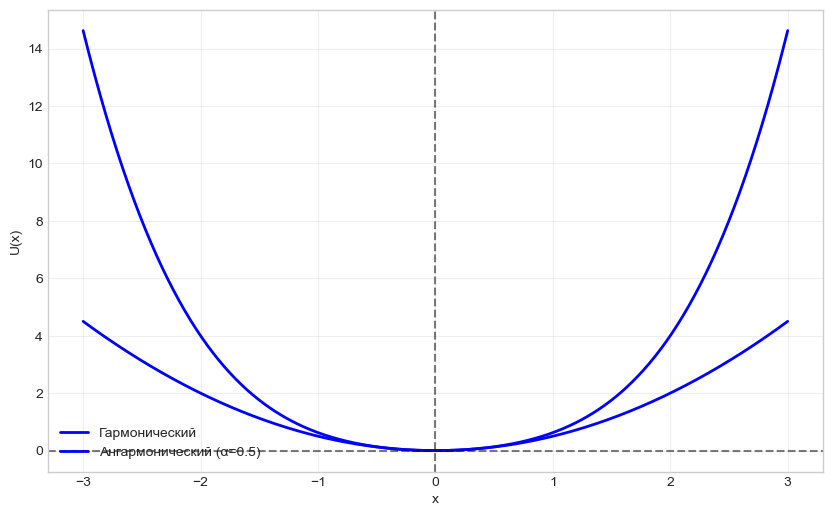

3. ФАЗОВЫЕ ПОРТРЕТЫ И ВРЕМЕННЫЕ ЗАВИСИМОСТИ

Анализ при δ = 0.0


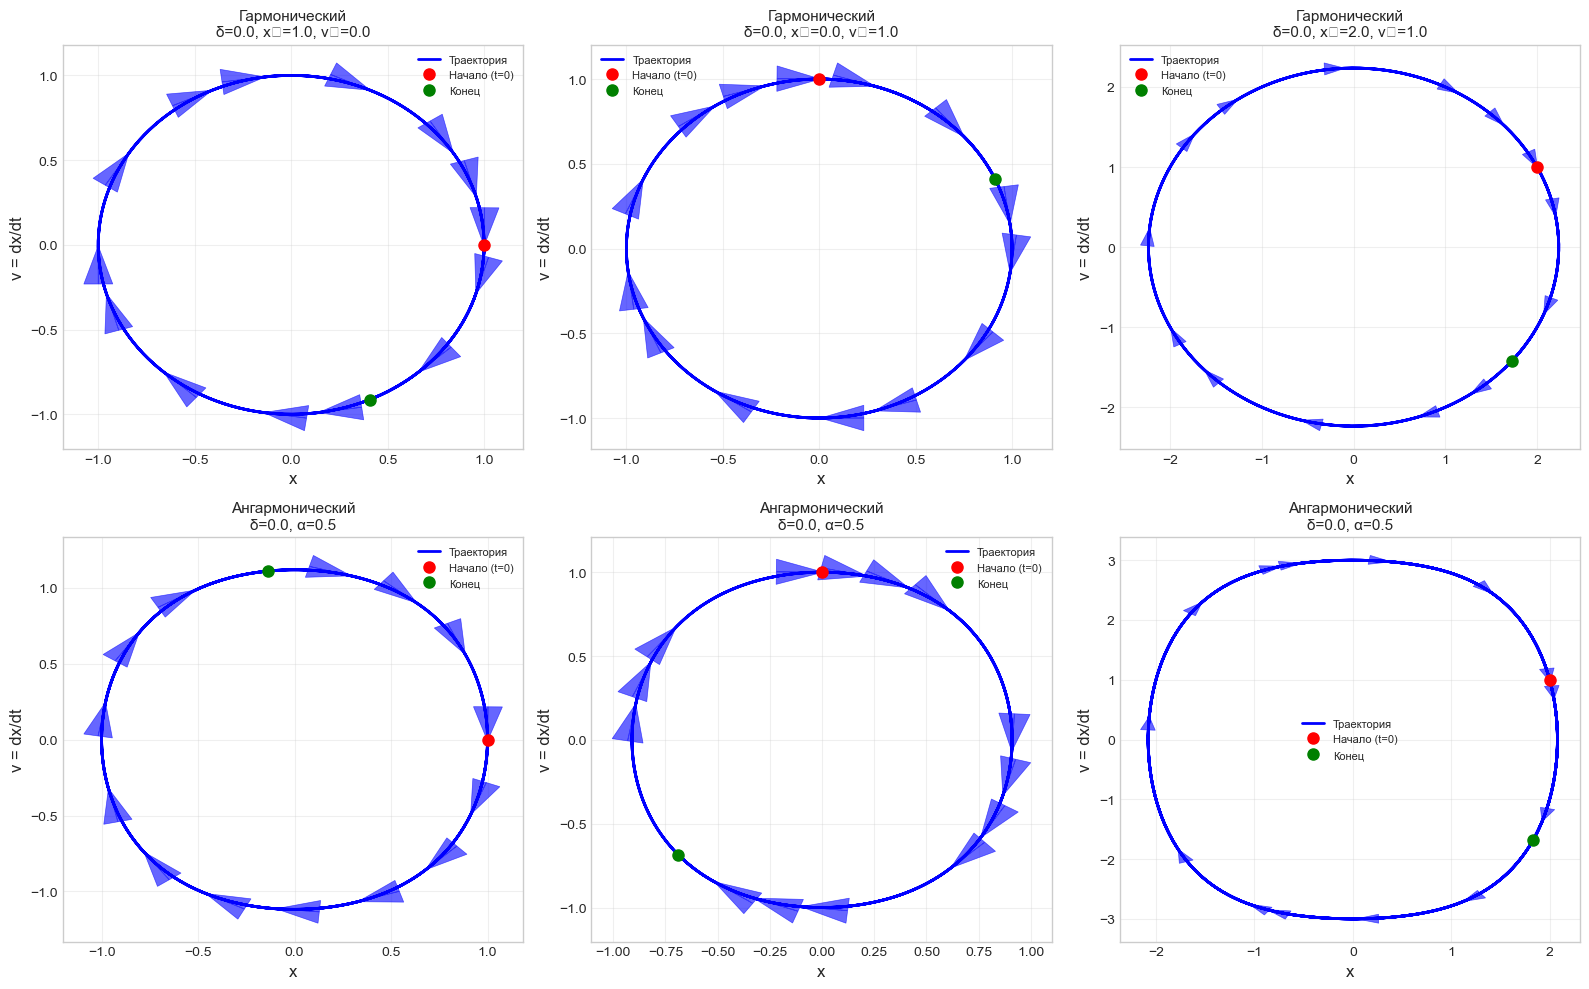

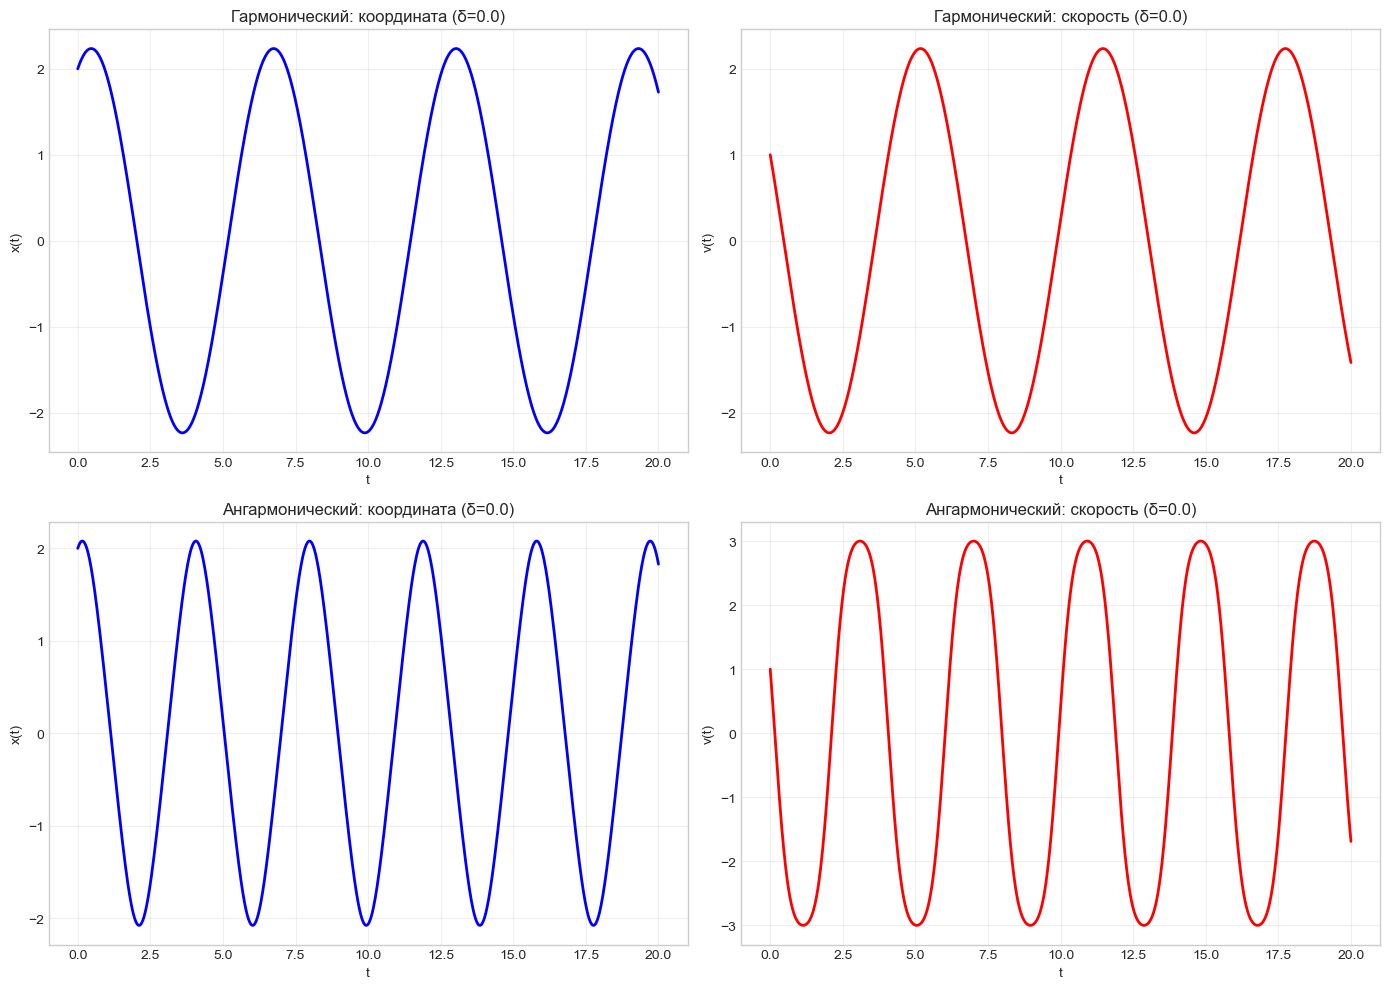


Анализ при δ = 0.3


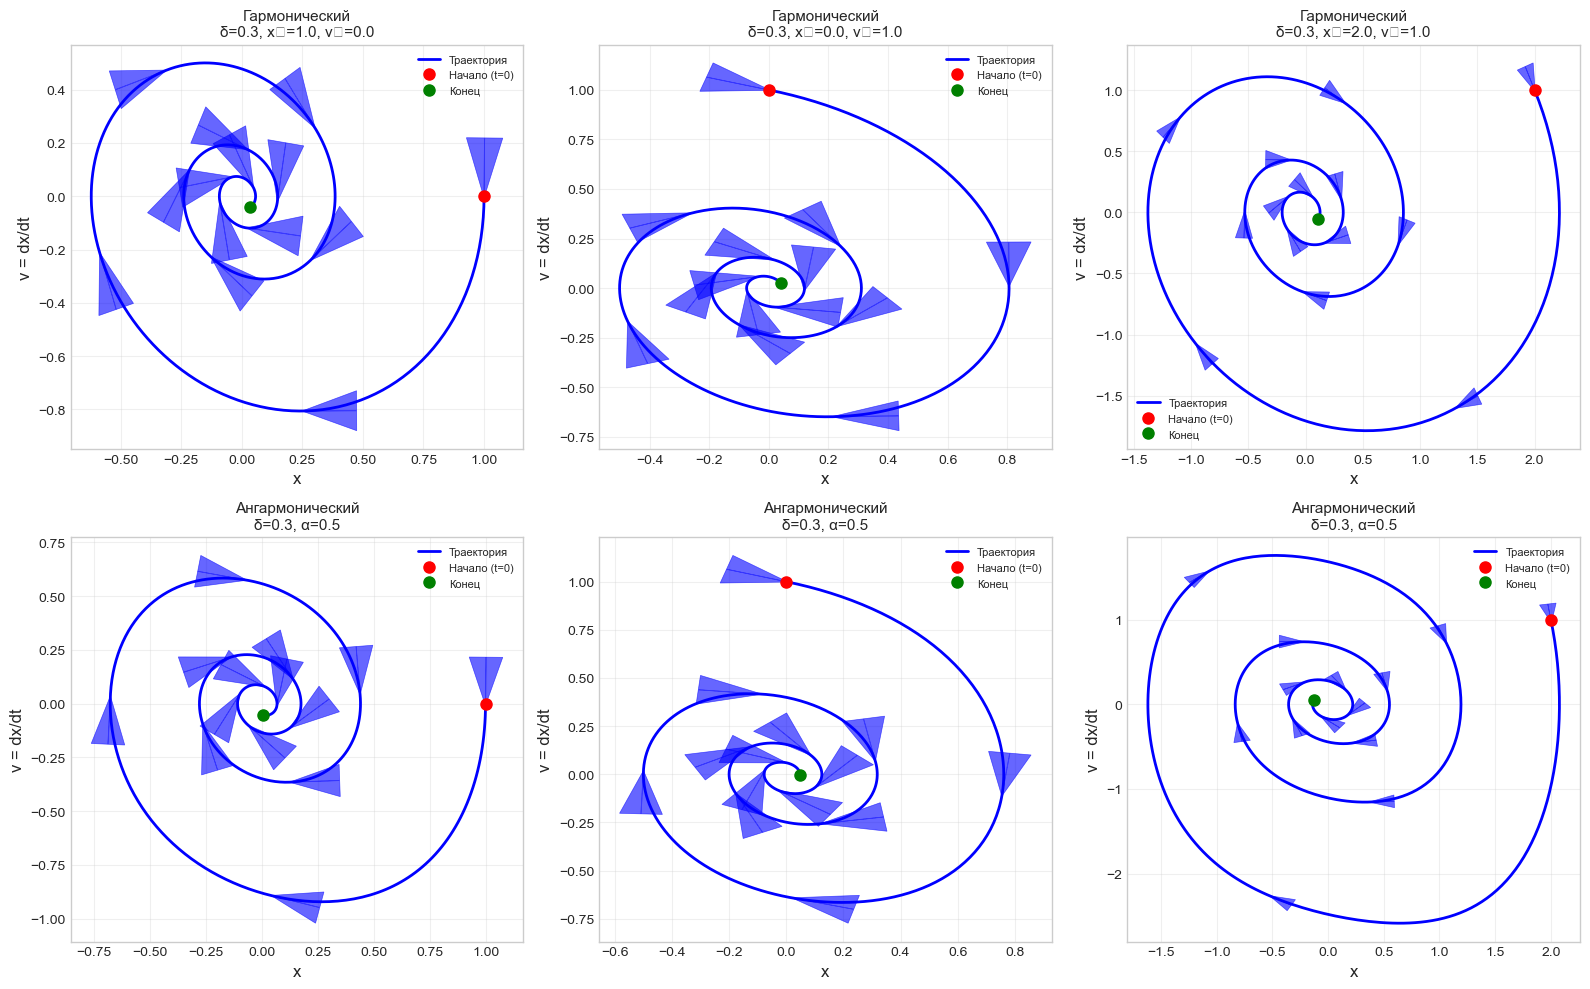

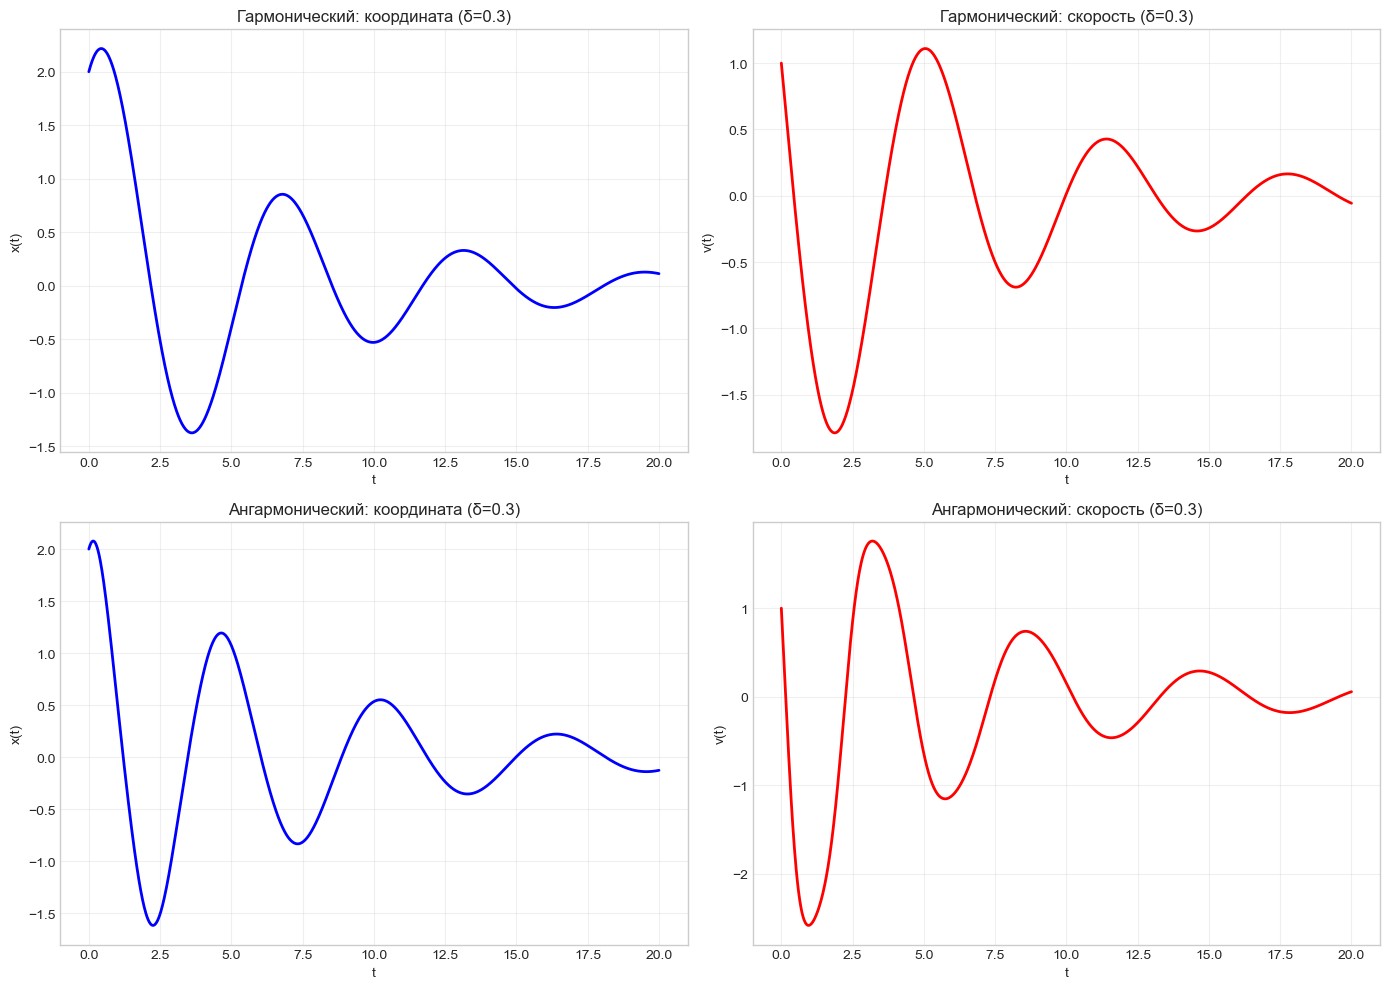


Анализ при δ = 0.8


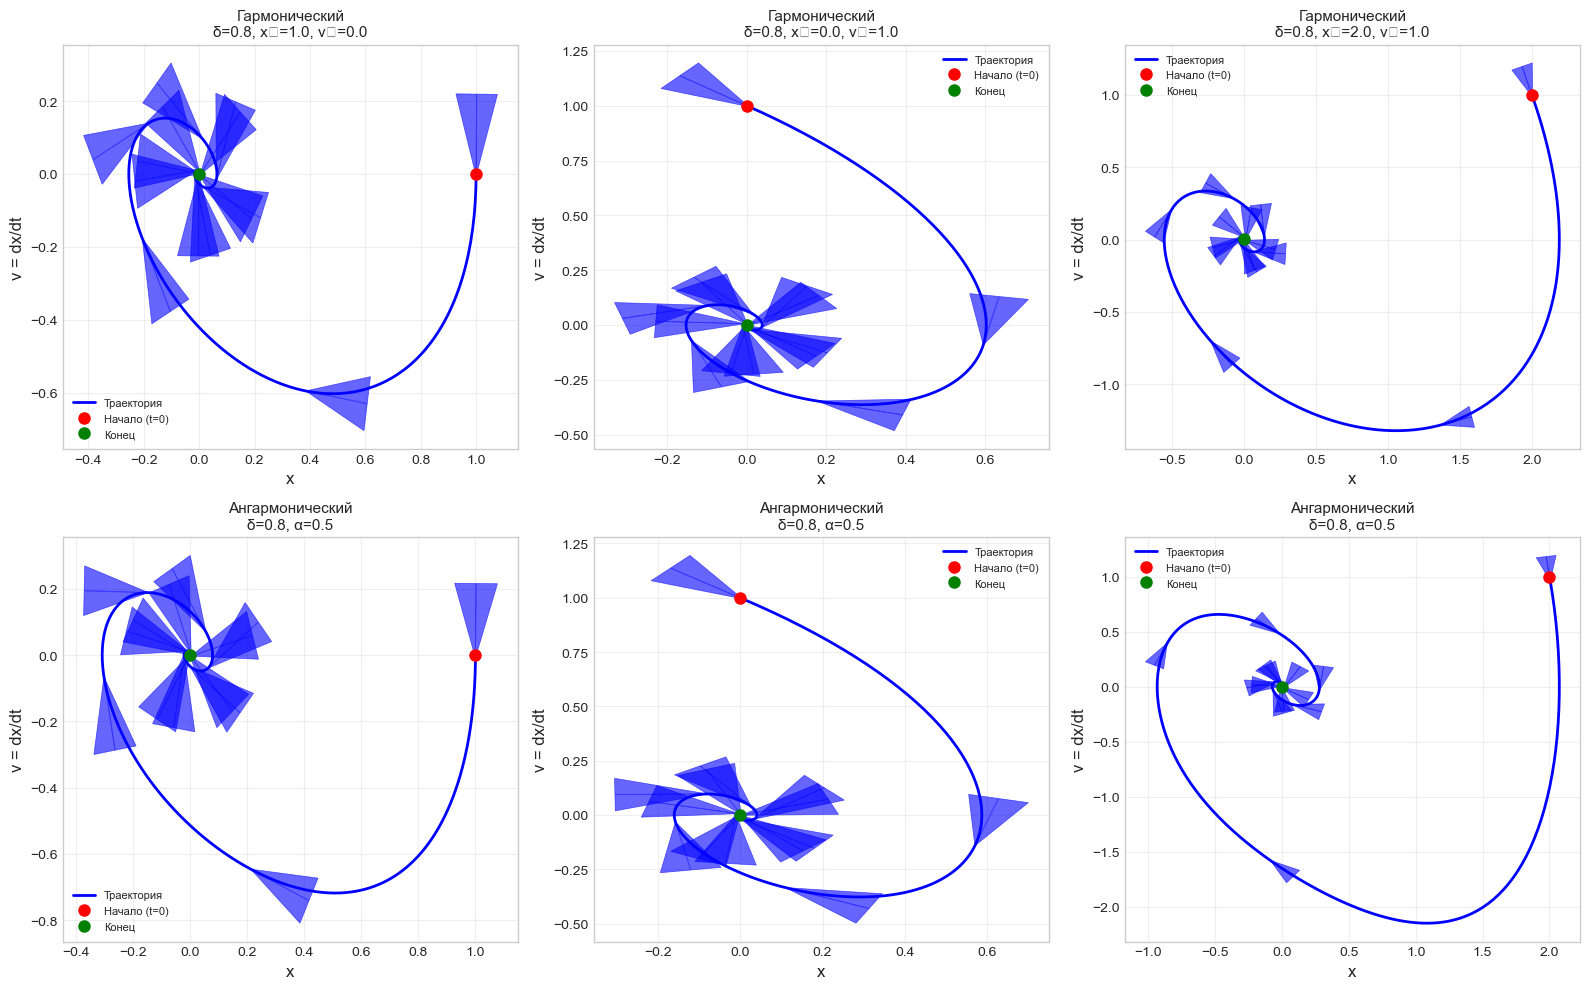

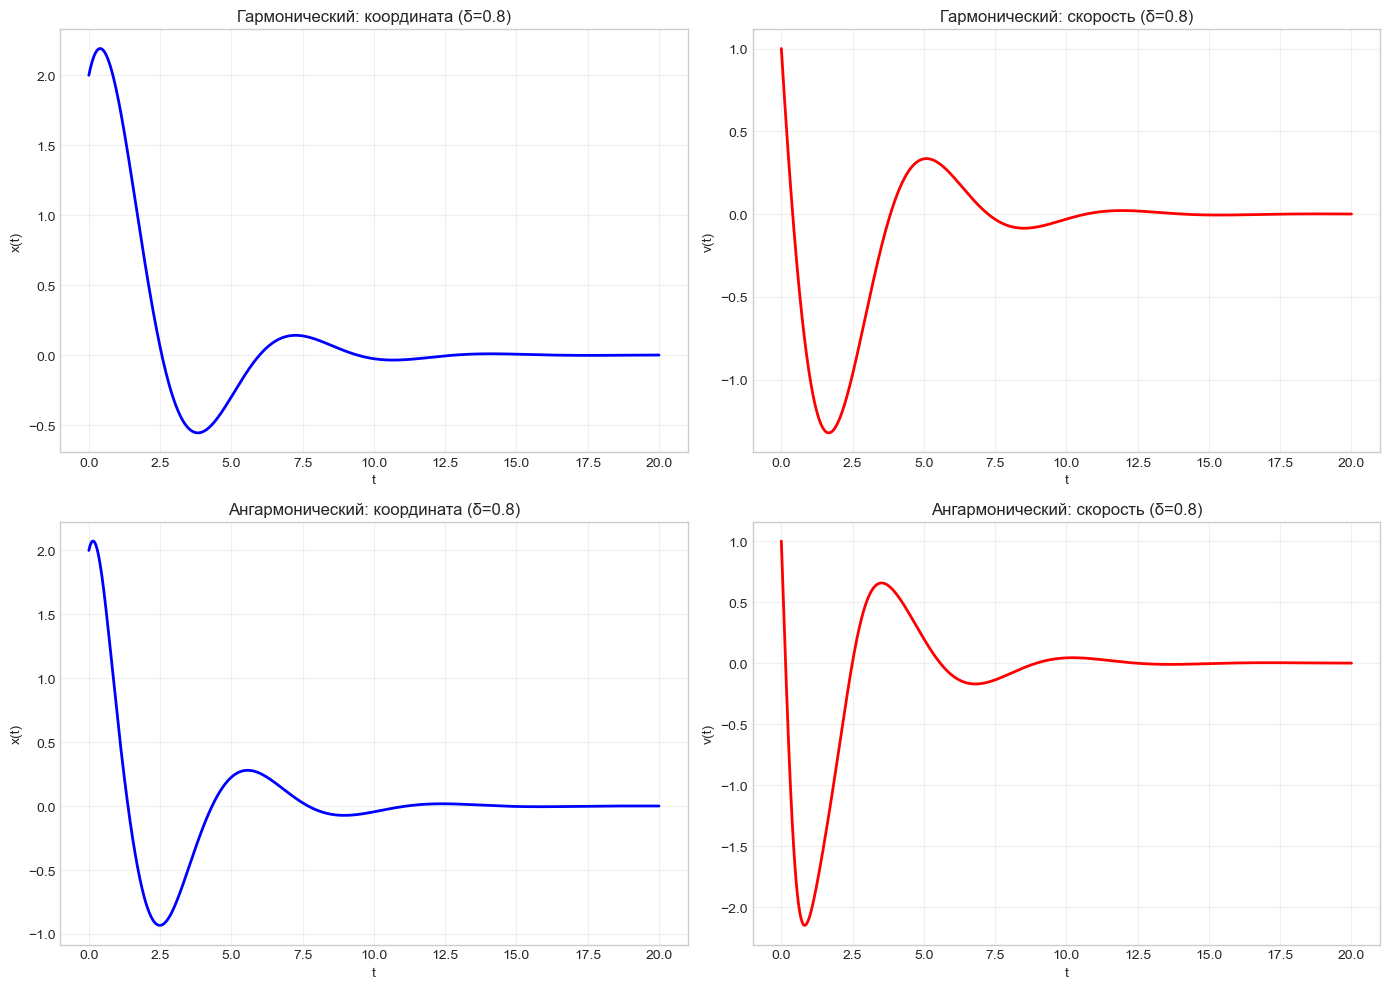

4. ПОВЕРХНОСТИ ЭНЕРГИИ (КОНСЕРВАТИВНЫЕ СЛУЧАИ, δ=0)


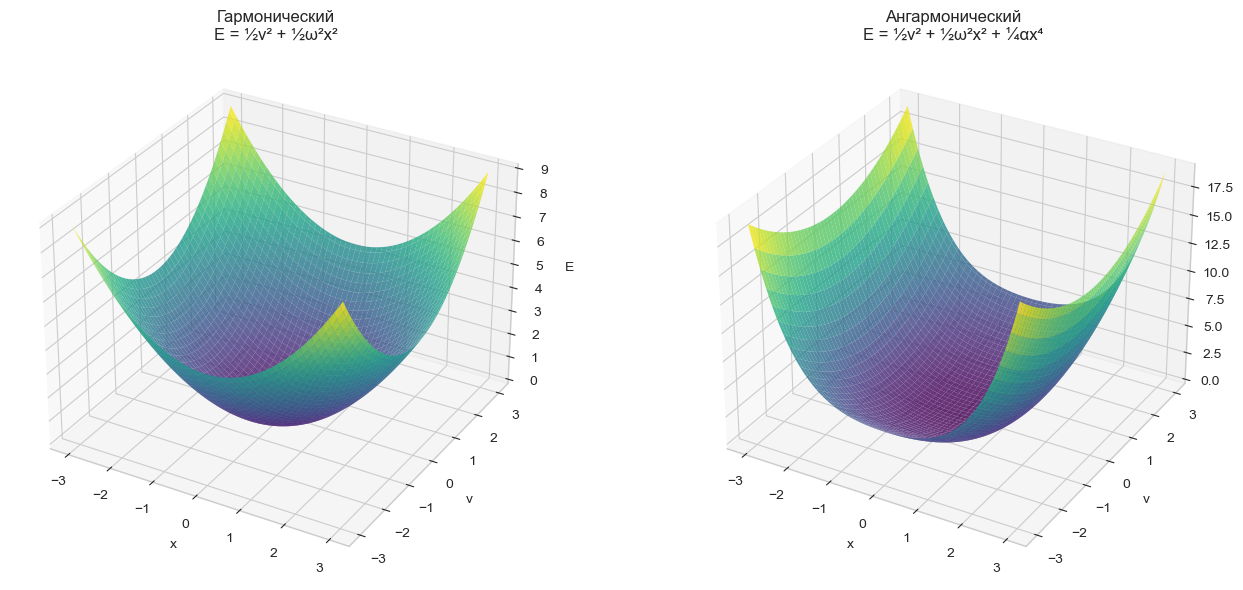

5. ФАЗОВЫЕ ПОРТРЕТЫ С РАЗЛИЧНЫМИ НАЧАЛЬНЫМИ УСЛОВИЯМИ


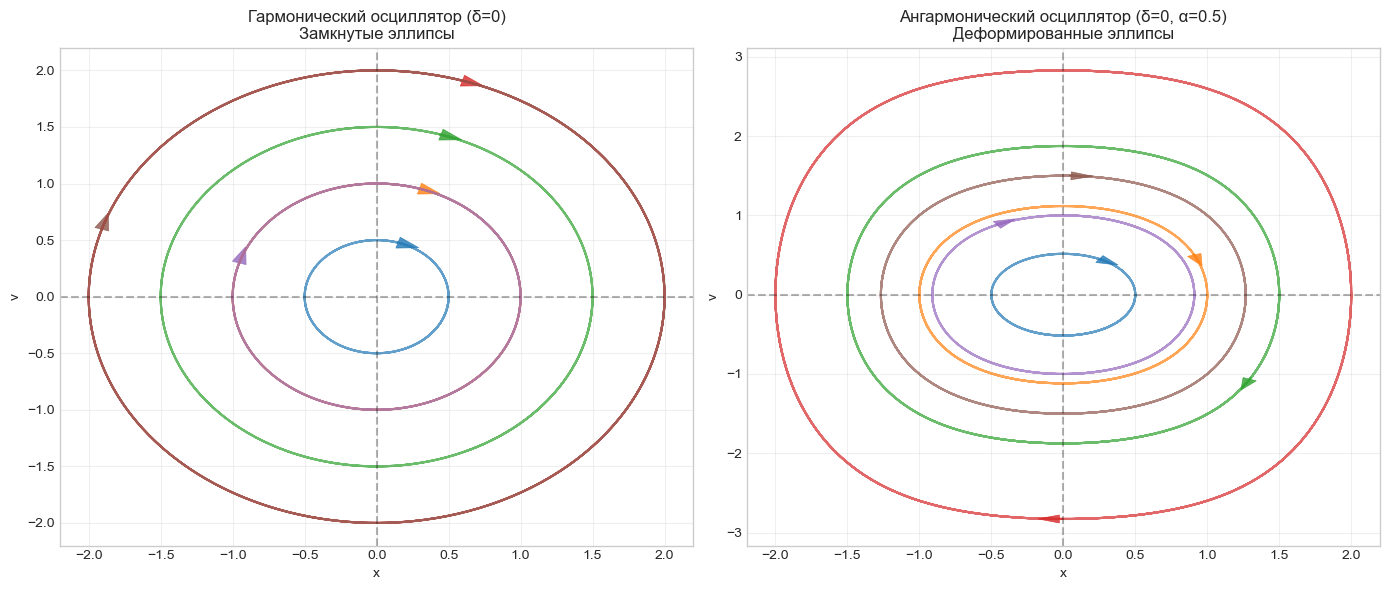

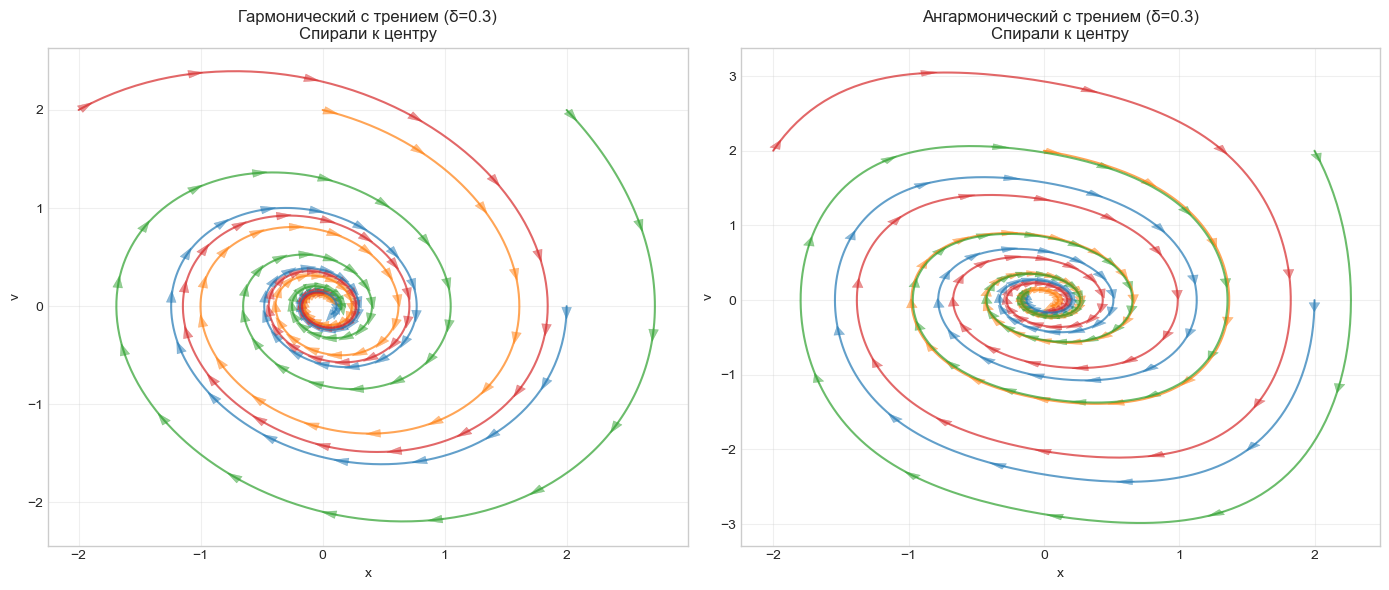

6. ВЛИЯНИЕ ПАРАМЕТРОВ ω И α


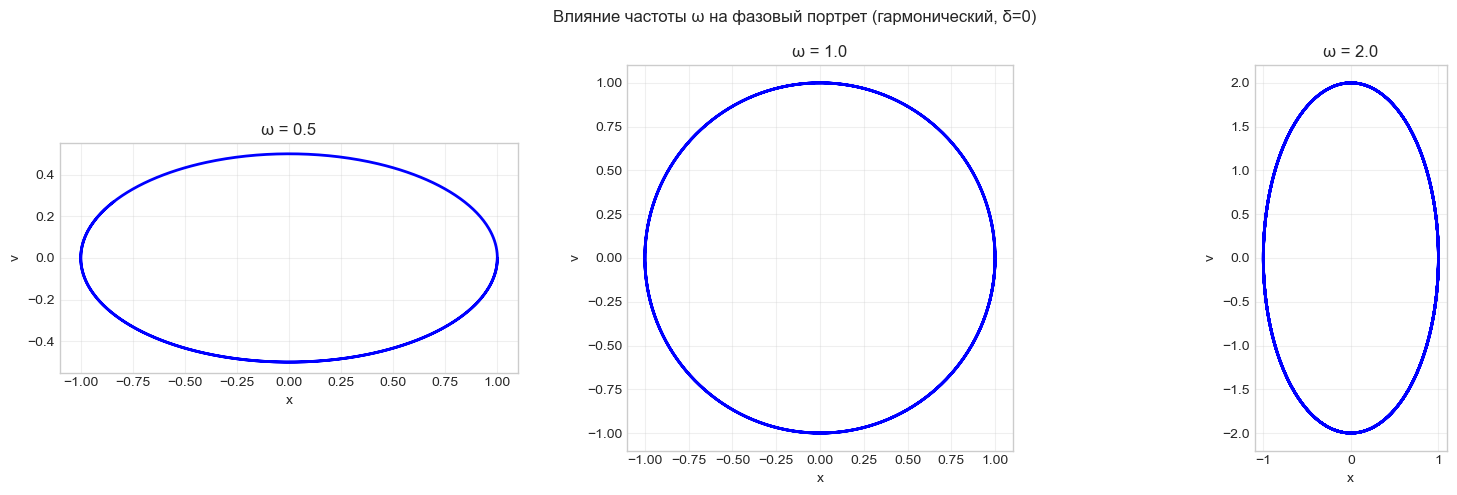

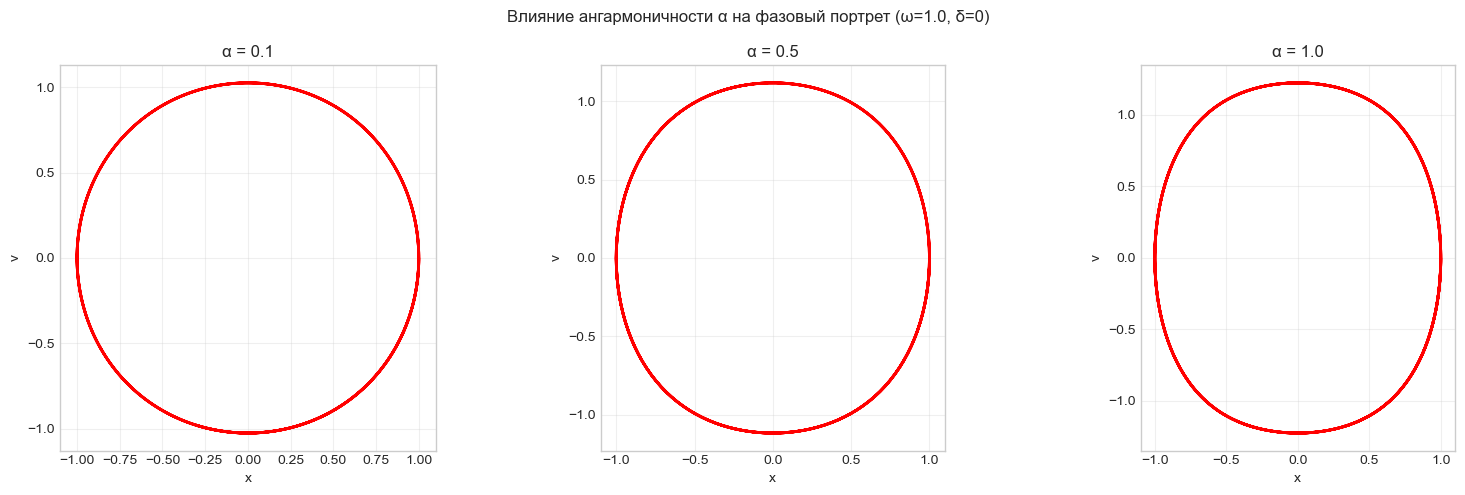

7. ДИССИПАЦИЯ ЭНЕРГИИ


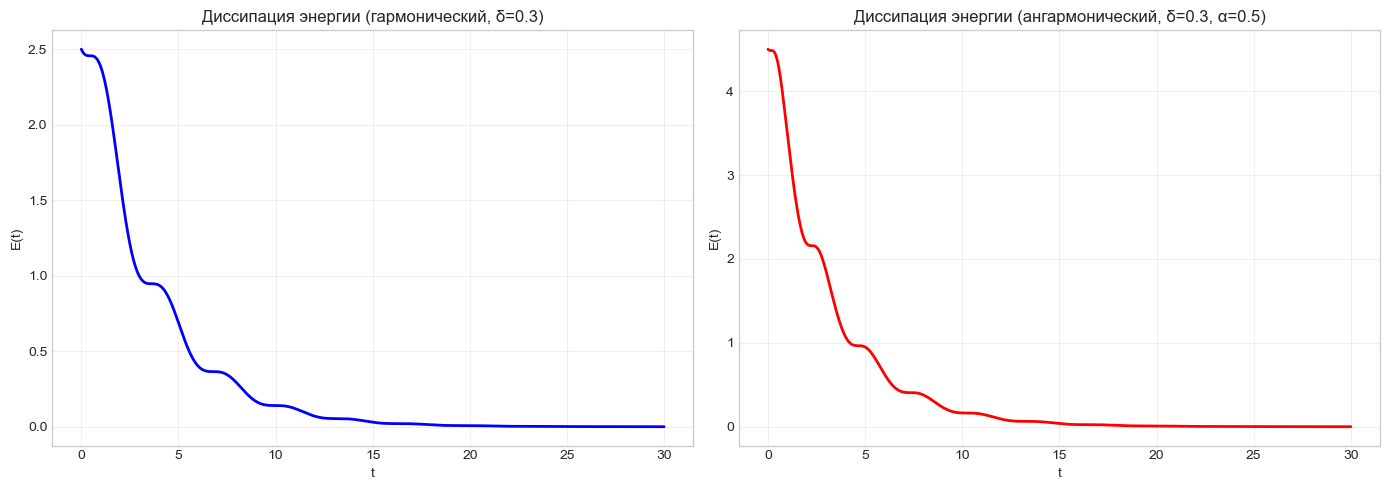

ВЫВОДЫ

1. ОСОБЫЕ ТОЧКИ:
   • Все системы имеют единственную особую точку (0, 0)
   • При δ=0: центр (нейтральная устойчивость, замкнутые траектории)
   • При δ>0: устойчивый фокус/узел (асимптотическая устойчивость)
   • Собственные значения: λ = -δ/2 ± √(δ²/4 - ω²)

2. ФАЗОВЫЕ ПОРТРЕТЫ:
   • Гармонический без трения: концентрические эллипсы
   • Гармонический с трением: спирали, сходящиеся к (0,0)
   • Ангармонический: деформированные эллипсы (более "острые" при больших x)
   • Направление движения: по часовой стрелке на фазовой плоскости (x, v)

3. ЭНЕРГЕТИЧЕСКИЙ АНАЛИЗ:
   • Консервативные системы (δ=0): E = const, фазовые траектории - 
     линии уровня поверхности энергии
   • Диссипативные системы (δ>0): dE/dt = -δv² < 0, энергия убывает
   • 3D поверхности энергии: параболоид (гармонический) и 
     "чаша" с quartic членом (ангармонический)

4. ПОТЕНЦИАЛЬНАЯ ФУНКЦИЯ:
   • U(x) = ½ω²x² (гармонический) - парабола
   • U(x) = ½ω²x² + ¼αx⁴ (ангармонический) - более крутой рост
   •

In [14]:
# 7. ОСНОВНОЙ АНАЛИЗ

print("1. ОСОБЫЕ ТОЧКИ И АНАЛИЗ УСТОЙЧИВОСТИ")
omega = 1.0
alpha = 0.5
delta_test = [0.0, 0.3, 0.8]

for delta in delta_test:
    print(f"\nδ = {delta}:")
    print("-"*60)
    harm = lyapunov_analysis_harmonic(omega, delta)
    anharm = lyapunov_analysis_anharmonic(omega, alpha, delta)
    print(f"  Гармонический:")
    print(f"    Особая точка: (0, 0)")
    print(f"    Тип: {harm['point_type']}")
    print(f"    Устойчивость: {harm['stability']}")
    print(f"    λ = {harm['eigenvalues']}")
    print(f"  Ангармонический:")
    print(f"    Особая точка: (0, 0)")
    print(f"    Тип: {anharm['point_type']}")
    print(f"    Устойчивость: {anharm['stability']}")
    print(f"    λ = {anharm['eigenvalues']}")


print("2. ПОТЕНЦИАЛЬНЫЕ ФУНКЦИИ")
print("Гармонический: U(x) = ½ω²x²")
print("Ангармонический: U(x) = ½ω²x² + ¼αx⁴")
print("\nМинимум потенциала при x=0 соответствует устойчивому равновесию")

fig_pot = plt.figure(figsize=(10, 6))
plot_potential(plt.gca(), [-3, 3], omega, alpha=None, title='Потенциальные функции (ω=1.0)')
plot_potential(plt.gca(), [-3, 3], omega, alpha=alpha, title='')
plt.savefig('potential_functions.png', dpi=300, bbox_inches='tight')
plt.show()


print("3. ФАЗОВЫЕ ПОРТРЕТЫ И ВРЕМЕННЫЕ ЗАВИСИМОСТИ")
initial_conditions = [[1.0, 0.0], [0.0, 1.0], [2.0, 1.0]]
t = np.linspace(0, 20, 1000)

for delta in delta_test:
    print(f"\nАнализ при δ = {delta}")
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for idx, y0 in enumerate(initial_conditions):
        # Гармонический
        sol_h = solve_system(harmonic_oscillator, y0, t, omega=omega, delta=delta)
        x_h, v_h = sol_h[:, 0], sol_h[:, 1]
        # Ангармонический
        sol_a = solve_system(anharmonic_oscillator, y0, t, 
                            omega=omega, alpha=alpha, delta=delta)
        x_a, v_a = sol_a[:, 0], sol_a[:, 1]
        # Фазовые портреты
        plot_phase_portrait(axes[0, idx], x_h, v_h, 
                          f'Гармонический\nδ={delta}, x₀={y0[0]}, v₀={y0[1]}',
                          delta, omega=omega)
        plot_phase_portrait(axes[1, idx], x_a, v_a,
                          f'Ангармонический\nδ={delta}, α={alpha}',
                          delta, omega=omega, alpha=alpha)
    plt.tight_layout()
    plt.savefig(f'phase_portraits_delta_{delta}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Временные зависимости
    fig_ts, axes_ts = plt.subplots(2, 2, figsize=(14, 10))
    y0 = [2.0, 1.0]
    
    sol_h = solve_system(harmonic_oscillator, y0, t, omega=omega, delta=delta)
    x_h, v_h = sol_h[:, 0], sol_h[:, 1]
    
    sol_a = solve_system(anharmonic_oscillator, y0, t, 
                        omega=omega, alpha=alpha, delta=delta)
    x_a, v_a = sol_a[:, 0], sol_a[:, 1]
    
    # Гармонический
    axes_ts[0, 0].plot(t, x_h, 'b-', linewidth=2)
    axes_ts[0, 0].set_xlabel('t')
    axes_ts[0, 0].set_ylabel('x(t)')
    axes_ts[0, 0].set_title(f'Гармонический: координата (δ={delta})')
    axes_ts[0, 0].grid(True, alpha=0.3)
    axes_ts[0, 1].plot(t, v_h, 'r-', linewidth=2)
    axes_ts[0, 1].set_xlabel('t')
    axes_ts[0, 1].set_ylabel('v(t)')
    axes_ts[0, 1].set_title(f'Гармонический: скорость (δ={delta})')
    axes_ts[0, 1].grid(True, alpha=0.3)

    # Ангармонический
    axes_ts[1, 0].plot(t, x_a, 'b-', linewidth=2)
    axes_ts[1, 0].set_xlabel('t')
    axes_ts[1, 0].set_ylabel('x(t)')
    axes_ts[1, 0].set_title(f'Ангармонический: координата (δ={delta})')
    axes_ts[1, 0].grid(True, alpha=0.3)
    axes_ts[1, 1].plot(t, v_a, 'r-', linewidth=2)
    axes_ts[1, 1].set_xlabel('t')
    axes_ts[1, 1].set_ylabel('v(t)')
    axes_ts[1, 1].set_title(f'Ангармонический: скорость (δ={delta})')
    axes_ts[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'time_series_delta_{delta}.png', dpi=300, bbox_inches='tight')
    plt.show()



print("4. ПОВЕРХНОСТИ ЭНЕРГИИ (КОНСЕРВАТИВНЫЕ СЛУЧАИ, δ=0)")
fig_3d = plt.figure(figsize=(14, 6))

ax1 = fig_3d.add_subplot(121, projection='3d')
plot_3d_energy(ax1, [-3, 3], [-3, 3], omega, alpha=None, title='Гармонический\nE = ½v² + ½ω²x²')

ax2 = fig_3d.add_subplot(122, projection='3d')
plot_3d_energy(ax2, [-3, 3], [-3, 3], omega, alpha=alpha, title=f'Ангармонический\nE = ½v² + ½ω²x² + ¼αx⁴')

plt.tight_layout()
plt.savefig('energy_surfaces.png', dpi=300, bbox_inches='tight')
plt.show()


print("5. ФАЗОВЫЕ ПОРТРЕТЫ С РАЗЛИЧНЫМИ НАЧАЛЬНЫМИ УСЛОВИЯМИ")
# Консервативные случаи (δ=0)
fig_conserv, axes_conserv = plt.subplots(1, 2, figsize=(14, 6))

# Гармонический без трения
for y0 in [[0.5, 0], [1.0, 0], [1.5, 0], [2.0, 0], [0, 1.0], [0, 2.0]]:
    sol = solve_system(harmonic_oscillator, y0, t, omega=omega, delta=0.0)
    x, v = sol[:, 0], sol[:, 1]
    axes_conserv[0].plot(x, v, linewidth=1.5, alpha=0.7)
    # Стрелка направления
    idx = len(x)//4
    axes_conserv[0].arrow(x[idx], v[idx], 
                         0.5*(x[idx+1]-x[idx]), 0.5*(v[idx+1]-v[idx]),
                         shape='full', lw=0.5, head_width=0.1, 
                         color=axes_conserv[0].lines[-1].get_color(), alpha=0.8)
axes_conserv[0].set_xlabel('x')
axes_conserv[0].set_ylabel('v')
axes_conserv[0].set_title('Гармонический осциллятор (δ=0)\nЗамкнутые эллипсы')
axes_conserv[0].grid(True, alpha=0.3)
axes_conserv[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_conserv[0].axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Ангармонический без трения
for y0 in [[0.5, 0], [1.0, 0], [1.5, 0], [2.0, 0], [0, 1.0], [0, 1.5]]:
    sol = solve_system(anharmonic_oscillator, y0, t, 
                      omega=omega, alpha=alpha, delta=0.0)
    x, v = sol[:, 0], sol[:, 1]
    axes_conserv[1].plot(x, v, linewidth=1.5, alpha=0.7)
    idx = len(x)//4
    axes_conserv[1].arrow(x[idx], v[idx],
                         0.5*(x[idx+1]-x[idx]), 0.5*(v[idx+1]-v[idx]),
                         shape='full', lw=0.5, head_width=0.1,
                         color=axes_conserv[1].lines[-1].get_color(), alpha=0.8)
axes_conserv[1].set_xlabel('x')
axes_conserv[1].set_ylabel('v')
axes_conserv[1].set_title(f'Ангармонический осциллятор (δ=0, α={alpha})\nДеформированные эллипсы')
axes_conserv[1].grid(True, alpha=0.3)
axes_conserv[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes_conserv[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('conservative_phase_portraits.png', dpi=300, bbox_inches='tight')
plt.show()

# Диссипативные случаи (δ>0)
fig_dissip, axes_dissip = plt.subplots(1, 2, figsize=(14, 6))
delta_dissip = 0.3
for y0 in [[2.0, 0], [0, 2.0], [2.0, 2.0], [-2.0, 2.0]]:
    # Гармонический с трением
    sol_h = solve_system(harmonic_oscillator, y0, t, omega=omega, delta=delta_dissip)
    x_h, v_h = sol_h[:, 0], sol_h[:, 1]
    axes_dissip[0].plot(x_h, v_h, linewidth=1.5, alpha=0.7)
    # Стрелка
    for idx in range(0, len(x_h)-5, 20):
        axes_dissip[0].arrow(x_h[idx], v_h[idx],
                            0.3*(x_h[idx+1]-x_h[idx]), 0.3*(v_h[idx+1]-v_h[idx]),
                            shape='full', lw=0.3, head_width=0.08,
                            color=axes_dissip[0].lines[-1].get_color(), alpha=0.5)
axes_dissip[0].set_xlabel('x')
axes_dissip[0].set_ylabel('v')
axes_dissip[0].set_title(f'Гармонический с трением (δ={delta_dissip})\nСпирали к центру')
axes_dissip[0].grid(True, alpha=0.3)

for y0 in [[2.0, 0], [0, 2.0], [2.0, 2.0], [-2.0, 2.0]]:
    # Ангармонический с трением
    sol_a = solve_system(anharmonic_oscillator, y0, t,
                        omega=omega, alpha=alpha, delta=delta_dissip)
    x_a, v_a = sol_a[:, 0], sol_a[:, 1]
    axes_dissip[1].plot(x_a, v_a, linewidth=1.5, alpha=0.7)
    for idx in range(0, len(x_a)-5, 20):
        axes_dissip[1].arrow(x_a[idx], v_a[idx],
                            0.3*(x_a[idx+1]-x_a[idx]), 0.3*(v_a[idx+1]-v_a[idx]),
                            shape='full', lw=0.3, head_width=0.08,
                            color=axes_dissip[1].lines[-1].get_color(), alpha=0.5)
axes_dissip[1].set_xlabel('x')
axes_dissip[1].set_ylabel('v')
axes_dissip[1].set_title(f'Ангармонический с трением (δ={delta_dissip})\nСпирали к центру')
axes_dissip[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dissipative_phase_portraits.png', dpi=300, bbox_inches='tight')
plt.show()


print("6. ВЛИЯНИЕ ПАРАМЕТРОВ ω И α")
# Разные частоты
fig_omega, axes_omega = plt.subplots(1, 3, figsize=(16, 5))
y0 = [1.0, 0.0]

for idx, om in enumerate(omega_values):
    sol = solve_system(harmonic_oscillator, y0, t, omega=om, delta=0.0)
    x, v = sol[:, 0], sol[:, 1]
    axes_omega[idx].plot(x, v, 'b-', linewidth=2)
    axes_omega[idx].set_title(f'ω = {om}')
    axes_omega[idx].set_xlabel('x')
    axes_omega[idx].set_ylabel('v')
    axes_omega[idx].grid(True, alpha=0.3)
    axes_omega[idx].set_aspect('equal')

plt.suptitle('Влияние частоты ω на фазовый портрет (гармонический, δ=0)')
plt.tight_layout()
plt.savefig('omega_influence.png', dpi=300, bbox_inches='tight')
plt.show()

# Разные alpha
fig_alpha, axes_alpha = plt.subplots(1, 3, figsize=(16, 5))
for idx, al in enumerate(alpha_values):
    sol = solve_system(anharmonic_oscillator, y0, t, 
                      omega=omega, alpha=al, delta=0.0)
    x, v = sol[:, 0], sol[:, 1]
    axes_alpha[idx].plot(x, v, 'r-', linewidth=2)
    axes_alpha[idx].set_title(f'α = {al}')
    axes_alpha[idx].set_xlabel('x')
    axes_alpha[idx].set_ylabel('v')
    axes_alpha[idx].grid(True, alpha=0.3)
    axes_alpha[idx].set_aspect('equal')

plt.suptitle(f'Влияние ангармоничности α на фазовый портрет (ω={omega}, δ=0)')
plt.tight_layout()
plt.savefig('alpha_influence.png', dpi=300, bbox_inches='tight')
plt.show()


print("7. ДИССИПАЦИЯ ЭНЕРГИИ")
fig_energy, axes_energy = plt.subplots(1, 2, figsize=(14, 5))
y0 = [2.0, 1.0]
t_long = np.linspace(0, 30, 1000)

# Гармонический
sol_h = solve_system(harmonic_oscillator, y0, t_long, omega=omega, delta=0.3)
x_h, v_h = sol_h[:, 0], sol_h[:, 1]
E_h = energy_harmonic(x_h, v_h, omega)
axes_energy[0].plot(t_long, E_h, 'b-', linewidth=2)
axes_energy[0].set_xlabel('t')
axes_energy[0].set_ylabel('E(t)')
axes_energy[0].set_title('Диссипация энергии (гармонический, δ=0.3)')
axes_energy[0].grid(True, alpha=0.3)

# Ангармонический
sol_a = solve_system(anharmonic_oscillator, y0, t_long, omega=omega, alpha=alpha, delta=0.3)
x_a, v_a = sol_a[:, 0], sol_a[:, 1]
E_a = energy_anharmonic(x_a, v_a, omega, alpha)
axes_energy[1].plot(t_long, E_a, 'r-', linewidth=2)
axes_energy[1].set_xlabel('t')
axes_energy[1].set_ylabel('E(t)')
axes_energy[1].set_title(f'Диссипация энергии (ангармонический, δ=0.3, α={alpha})')
axes_energy[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('energy_dissipation.png', dpi=300, bbox_inches='tight')
plt.show()


print("ВЫВОДЫ")

print("""
1. ОСОБЫЕ ТОЧКИ:
   • Все системы имеют единственную особую точку (0, 0)
   • При δ=0: центр (нейтральная устойчивость, замкнутые траектории)
   • При δ>0: устойчивый фокус/узел (асимптотическая устойчивость)
   • Собственные значения: λ = -δ/2 ± √(δ²/4 - ω²)

2. ФАЗОВЫЕ ПОРТРЕТЫ:
   • Гармонический без трения: концентрические эллипсы
   • Гармонический с трением: спирали, сходящиеся к (0,0)
   • Ангармонический: деформированные эллипсы (более "острые" при больших x)
   • Направление движения: по часовой стрелке на фазовой плоскости (x, v)

3. ЭНЕРГЕТИЧЕСКИЙ АНАЛИЗ:
   • Консервативные системы (δ=0): E = const, фазовые траектории - 
     линии уровня поверхности энергии
   • Диссипативные системы (δ>0): dE/dt = -δv² < 0, энергия убывает
   • 3D поверхности энергии: параболоид (гармонический) и 
     "чаша" с quartic членом (ангармонический)

4. ПОТЕНЦИАЛЬНАЯ ФУНКЦИЯ:
   • U(x) = ½ω²x² (гармонический) - парабола
   • U(x) = ½ω²x² + ¼αx⁴ (ангармонический) - более крутой рост
   • Минимум при x=0 ↔ устойчивое положение равновесия
   • Фазовые траектории пересекают линии уровня потенциала

5. ВЛИЯНИЕ ПАРАМЕТРОВ:
   • ω ↑ → частота колебаний ↑, эллипсы "уже"
   • α ↑ → нелинейность ↑, асимметрия фазовых портретов
   • δ ↑ → скорость затухания ↑, быстрее сходимость к равновесию

6. РАЗЛИЧИЯ ГАРАМОНИЧЕСКОГО И АНГАРАМОНИЧЕСКОГО:
   • Гармонический: изохронность (период не зависит от амплитуды)
   • Ангармонический: период зависит от амплитуды
   • При малых отклонениях ангармонический → гармонический

7. ПРАКТИЧЕСКОЕ ЗНАЧЕНИЕ:
   • Гармонический осциллятор - линейное приближение малых колебаний
   • Ангармонический - учет нелинейности при больших амплитудах
   • Трение необходимо для описания реальных диссипативных систем
   • Анализ устойчивости важен для понимания долговременного поведения

8. НАПРАВЛЕНИЕ ДВИЖЕНИЯ:
   • При v > 0: x растет (движение вправо)
   • При v < 0: x убывает (движение влево)
   • На фазовой плоскости: движение по часовой стрелке
   • Стрелки на графиках показывают направление возрастания времени
""")